# Importing libraries

In [ ]:
import numpy as np
import scipy
import math
import matplotlib
from scipy import optimize
from scipy import special
from scipy.optimize import root
from scipy.special import jv
from matplotlib.lines import Line2D
import sympy as sp
import matplotlib.pyplot as plt

# Code cell 1

import_root_gabbard evaluates the coefficients of Al and d/dt Al of the non-dimensionalized equation shown in Gabbard et al. (2025) (eq 3.16), for a given Ohnesorge number (Oh) and mode number (L).

Based on the equivalent expression of these coefficients in terms of qa and qb, 4 potential roots in q are found. The two values of q, which are real-positive with the real value are returned as qa and qb.

This function works to "Import" qa and qb based off Gabbard et al. (2025)'s estimated coefficients. These imported values are only identical to the true values of qa and qb at Oh = 0

In [ ]:
# Arguments: Ohnesorge number (Oh), mode number (L)
# Returns: Imported roots (qa, qb)

def import_root_gabbard(Oh, l):
    k1 = 2*(2*l+1)*(l-1)*Oh
    k2 = l*(l+2)*(l-1)
    q1 = ((k1+(k1**2-4*k2)**0.5)/2)**0.5
    q2 = -((k1+(k1**2-4*k2)**0.5)/2)**0.5
    q3 = ((k1-(k1**2-4*k2)**0.5)/2)**0.5
    q4 = -((k1-(k1**2-4*k2)**0.5)/2)**0.5

    candidates = [q1, q2, q3, q4]

    # Filter roots with positive real part
    positive_real = [q for q in candidates if q.real > 0]

    # Sort by smallest real part (closest to zero)
    smallest_positive = sorted(positive_real, key=lambda x: x.real)[:2]

    return smallest_positive[0], smallest_positive[1]

# Code cell 2

For a given Oh and L, newton_complex takes a starting point "q", the tolerance for the value of the objective function, the tolerance for the difference in the objective function between iterations and the max number of iterations to iteratively solve for a solution for the characteristic equation.

The characteristic equation is equation 20 of Reid (1960), where we take the LHS - RHS.

In Reid (1960), equation 20 is written such that Q(l+1/2) = J(l+3/2)/J(l+1/2) In this implementation, we ignore the convention of writing the subscript of Q.This is because the orders of the bessel functions J depend only on the value of l making the subscript for Q, the ratios of said bessel functions, redundant.

Due to a limit in the values jv() from SciPy can use as inputs, past a certain ampltidue for the input value, a continued fraction approximation is used. The following resources describe this method.

https://math.stackexchange.com/questions/4835453/a-ratio-of-bessel-functions-with-a-similar-continued-fraction-expansion-to-e1

https://pubs.aip.org/aip/cip/article-pdf/4/4/403/11813696/403_1_online.pdf


In [ ]:
### Ratio of bessel functions of the first kind.
### Formulations are different as scipy's jv returns inf past abs(q) = 1000
### This necessitates the approximation of the ratio Q, using continued fractions

### Arguments: Order of bessel function (v), input variable (x)
### Returns: Value of the bessel ratio Q

### The reason behind the insanely code-heavy implementation of the bessel ratio Q,
### Is so that it can be used for plotting in Code cell 4. if not for continuous
### root plotting, a simpler form, archived in code cell 6, can be used.


def Q(v, x):
    x = np.asarray(x)

    def Q_continued_fraction(v, x):
        N = 100
        eps = 1e-14
        nu = v + 0.5
        cf = np.zeros_like(x, dtype=complex)
        for k in reversed(range(1, N+1)):
            denom = 2*(nu + k) - cf
            denom = np.where(np.abs(denom) < eps, denom + eps, denom)
            cf = x**2 / denom
        denom = 2*(nu+1) - cf
        denom = np.where(np.abs(denom) < eps, denom + eps, denom)
        return x / denom

    def Q_analytical(v, x):
        return jv(v+(3/2), x)/jv(v+(1/2), x)

    x_abs = np.abs(x)
    result = np.empty_like(x, dtype=complex)
    mask = x_abs < 900
    result[mask] = Q_analytical(v, x[mask])
    result[~mask] = Q_continued_fraction(v, x[~mask])

    # Return scalar if scalar input
    return result.item() if result.shape == () else result

### Objective function is F(q), such that it is LHS - RHS of the characteristic transcendental equation
def objective_function(Oh, l, q):
    q = np.asarray(q)

    if Oh == 0:
        result = (l)*(l-1)*(l+2) + (q)**4
    else:
        sqrtOh = Oh**0.5
        Qval = Q(l, q/sqrtOh)
        numerator = q - 2*l*sqrtOh*Qval
        denominator = q - 2*sqrtOh*Qval
        result = (l)*(l-1)*(l+2) + (q)**4 - (2*Oh*(q**2)*(l-1)*(l + (l+1)*(numerator/denominator)))

    return result.item() if result.shape == () else result

### F represents the vector values objective function, separating Re and Im
def objective_F(Oh, l, x, y):
    q = x + 1j*y
    val = objective_function(Oh, l, q)
    return np.array([np.real(val), np.imag(val)])

### Center derivative based jacobian function, h represents step size
def jacobian(Oh, l, x, y, h):
    np.set_printoptions(precision=6, suppress=True)
    fx1 = objective_F(Oh, l, x + h/2, y)
    fx2 = objective_F(Oh, l, x - h/2, y)
    fy1 = objective_F(Oh, l, x, y + h/2)
    fy2 = objective_F(Oh, l, x, y - h/2)
    dfdx = (fx1 - fx2)/h
    dfdy = (fy1 - fy2)/h
    J = np.column_stack((dfdx, dfdy))
    return J

### Complex multivariable newton method. x0 and y0 represent the starting guess
### tol_F is the tolerance for the value of the objective function
### tol_step is the tolerance of the step size between guesses
### deriv_step is the value of h to find the numerical jacobian
def newton_complex(Oh, l, q, tol_F=1e-12, tol_step=1e-12, deriv_step = 1e-8, max_iter=100):
    x = q.real
    y = q.imag
    F_val = objective_F(Oh, l, x, y)

    if np.linalg.norm(F_val) < tol_F:
        return x + 1j*y

    for i in range(max_iter):

        J = jacobian(Oh, l, x, y, deriv_step)
        step = np.linalg.lstsq(J, F_val, rcond=None)[0] ### Least Squares method solution for robustness, given bessel functions
        x_new = x - step[0]
        y_new = y - step[1]
        step_size = np.linalg.norm([x_new-x, y_new-y]) ### Evaluating modular value of step size
        F_val = objective_F(Oh, l, x_new, y_new)

        ### if the difference between steps is small enough, terminate
        if step_size < tol_step and np.linalg.norm(F_val) < tol_F:
            return x_new + 1j*y_new

        ### Update values
        x = x_new
        y = y_new

    ### if the max number of iterations is exhausted, terminate
    return x + 1j*y

#Code cell 3

plot_roots produces a plot of the roots of the transcendental equation for given parameters Oh and L, along with two complex points. The use case is to check whether a found set of roots qa and qb lie are indeed the correct roots of the transcendental equation.

The true roots of the transcendental equation are shown through the intersection of two contour plots. The imaginary and real parts of the transcendental equation individually represent a surface plot. At z = 0, we achieve two contour curves such that the intersection between the two contour plot curves represent the complex roots of the transcendental equation.

Atop these two contour curves, two complex points are plotted.

In [ ]:
def plot_roots(qa, qb, Oh, l, caption, N=100):

  a = np.linspace(0, abs(qa.real) + 5, N)
  b = np.linspace(-abs(qb.imag) - 5, abs(qb.imag) + 5, N)
  A, B = np.meshgrid(a, b)
  q = A + 1j*B

  F_vals = objective_function(Oh, l, q)
  F_real = np.real(F_vals)
  F_imag = np.imag(F_vals)

  plt.figure(figsize=(8,8))

  # Plot contours
  c1 = plt.contour(A, B, F_real, levels=[0], colors='red', linewidths=2)
  c2 = plt.contour(A, B, F_imag, levels=[0], colors='blue', linewidths=2)
  p1 = plt.scatter(qa.real, qa.imag, color='black', s=40, zorder=5)
  p2 = plt.scatter(qb.real, qb.imag, color='black', s=40, zorder=5)
  plt.xlabel('Re(q)')
  plt.ylabel('Im(q)')
  plt.title(f'L = {l}, Oh = {Oh} ' + caption)

  plt.grid()
  plt.show()


#Code cell 4

continuation-vis visualizes how the coefficients of the non-dimensionalized differential equation for L = 2 to 90, for a given Ohnesorge number, is found with the Ohnesorge-Mode number continuation.

This is done by starting with the roots qa and qb for Oh = 0, L = 2, at which point Gabbard et al (2025)'s estimation is identical to the true roots. This point is imported using import_root_gabbard.


This value of qa and qb is used as the starting point for the first continuation, in Oh. Under the specified continuation_step_size, The value of qa and qb is found for the specified Oh and L = 2.


This value of qa and qb is used as the starting point for the second continuation, in L. For Nth iteration for N from 2 to 90, the roots qa and qb are found for specified Oh and L = N, with the roots qa and qb for L = N serving as the initial point in the newton method to look for roots for L = N+1.

The function returns the coefficient's real values scattered against mode number L, for both Al and d/dt Al. If plot_approx is set to True, then the approximation curve from Gabbard et al (2025) is overlayed. For higher Oh, it is suggested that plot_approx is kept off, as the massive deviations results in the scales of the scatterplot being illegible.

If plot_trans is set to true, the initial values of qa and qb imported from gabbard et al are plotted against the Oh = 0, L = 2 case.

Following that, the values of qa and qb following the continuation method in Oh is also plotted, showing the case for Oh = target Oh and L = 2

Then, for each value of L from 2 to N, the found roots qa and qb is plotted against the respective contour plot as well.


Note: this method, of continuing twice in this order, takes advantage of the progression of the nature of the smallest real-positive roots' progression as both Oh and L increases in order to maximize stability.

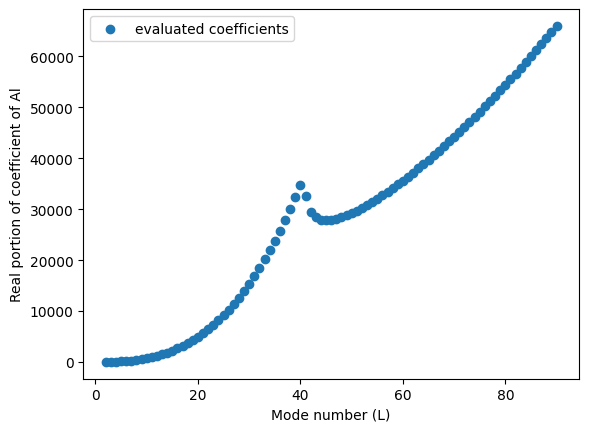

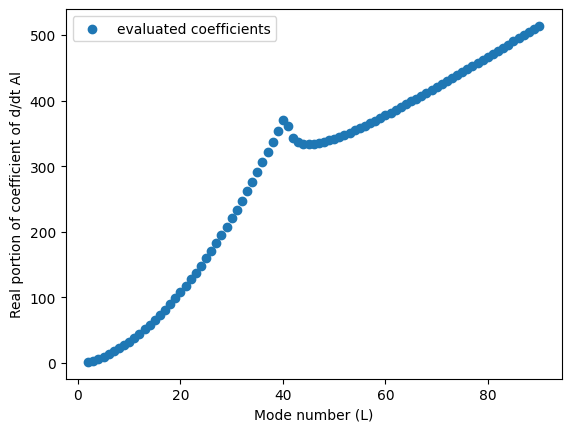

0.2 0.2


In [ ]:
def continuation_vis(target_Oh, target_L, continuation_step_size=0.01, plot_approx=False, plot_trans = False):

  list_of_coef_A = []
  list_of_coef_A_first = []

  Oh_cont_seed_a = import_root_gabbard(0, 2)[0]
  Oh_cont_seed_b = import_root_gabbard(0, 2)[1]
  plot_roots(Oh_cont_seed_a, Oh_cont_seed_b, 0, 2, "Seed for Oh-Cont", 50) if plot_trans else None

  current_qa = Oh_cont_seed_a
  current_qb = Oh_cont_seed_b

  n = int(round(target_Oh / continuation_step_size))

  for k in range(1, n + 1):
    current_Oh = min(k * continuation_step_size, target_Oh)
    next_qa = newton_complex(current_Oh, 2, current_qa)
    next_qb = newton_complex(current_Oh, 2, current_qb)
    current_qa = next_qa
    current_qb = next_qb

  target_qa = current_qa
  target_qb = current_qb
  plot_roots(target_qa, target_qb, target_Oh, 2, "Seed for L-Cont", 50) if plot_trans else None

  L_cont_seed_a = target_qa
  L_cont_seed_b = target_qb

  current_qa_l = L_cont_seed_a
  current_qb_l = L_cont_seed_b

  for l in range(2, target_L+1):
    next_qa_l = newton_complex(target_Oh, l, current_qa_l)
    next_qb_l = newton_complex(target_Oh, l, current_qb_l)

    current_qa_l = next_qa_l
    current_qb_l = next_qb_l

    plot_roots(current_qa_l, current_qb_l, target_Oh, l, "Oh-Continuation", 50) if plot_trans else None

    calculated_coef_A = (current_qa_l**2)*(current_qb_l**2)
    calculated_coef_A_first = (current_qa_l**2 + current_qb_l**2)

    list_of_coef_A.append((l, calculated_coef_A))
    list_of_coef_A_first.append((l, calculated_coef_A_first))


  l_vals = np.array([item[0] for item in list_of_coef_A])
  l_smooth = np.linspace(min(l_vals), max(l_vals), 500)
  complex_vals_A = np.array([item[1] for item in list_of_coef_A])
  approx_eq_A = l_smooth*(l_smooth+2)*(l_smooth-1)
  complex_vals_A_first = np.array([item[1] for item in list_of_coef_A_first])
  approx_eq_A_first = 2*(2*l_smooth+1)*(l_smooth-1)*(target_Oh)

  real_parts_A = complex_vals_A.real
  real_parts_A_first = complex_vals_A_first.real


  if plot_approx:

    plt.figure()
    plt.scatter(l_vals, real_parts_A, label = "evaluated coefficients")
    plt.plot(l_smooth, approx_eq_A, linewidth=2, color = "orange", label = "approximate equation")
    plt.xlabel('Mode number (L)')
    plt.ylabel(f'Real portion of coefficient of Al' )
    plt.legend()
    plt.show()

    plt.figure()
    plt.scatter(l_vals, real_parts_A_first, label = "evaluated coefficients")
    plt.plot(l_smooth, approx_eq_A_first, linewidth=2, color = "orange", label = "approximate equation")
    plt.xlabel('Mode number (L)')
    plt.ylabel(f'Real portion of coefficient of d/dt Al' )
    plt.legend()
    plt.show()

  else:

    plt.figure()
    plt.scatter(l_vals, real_parts_A, label = "evaluated coefficients")
    plt.xlabel('Mode number (L)')
    plt.ylabel(f'Real portion of coefficient of Al' )
    plt.legend()
    plt.show()

    plt.figure()
    plt.scatter(l_vals, real_parts_A_first, label = "evaluated coefficients")
    plt.xlabel('Mode number (L)')
    plt.ylabel(f'Real portion of coefficient of d/dt Al' )
    plt.legend()
    plt.show()
  print(current_Oh, target_Oh)

test_Oh = 0.2
Oh_continuation_step = 0.001
test_L = 90
continuation_vis(test_Oh, test_L, Oh_continuation_step, False, False)

### Test Oh = 0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.

#Code cell 5

Implementation identical as above, except it only returns raw data, to be used in the actual implementation in larger code.

In [ ]:
def continuation_coef_finder(target_Oh, target_L):

  list_of_coef_A = []
  list_of_coef_A_first = []

  Oh_cont_seed_a = import_root_gabbard(0, 2)[0]
  Oh_cont_seed_b = import_root_gabbard(0, 2)[1]

  current_qa = Oh_cont_seed_a
  current_qb = Oh_cont_seed_b

  continuation_step_size = target_Oh/100
  n = int(round(target_Oh / continuation_step_size))

  for k in range(1, n + 1):
    current_Oh = min(k * continuation_step_size, target_Oh)
    next_qa = newton_complex(current_Oh, 2, current_qa)
    next_qb = newton_complex(current_Oh, 2, current_qb)
    current_qa = next_qa
    current_qb = next_qb

  target_qa = current_qa
  target_qb = current_qb

  L_cont_seed_a = target_qa
  L_cont_seed_b = target_qb

  current_qa_l = L_cont_seed_a
  current_qb_l = L_cont_seed_b

  for l in range(2, target_L+1):
    next_qa_l = newton_complex(target_Oh, l, current_qa_l)
    next_qb_l = newton_complex(target_Oh, l, current_qb_l)

    current_qa_l = next_qa_l
    current_qb_l = next_qb_l

    calculated_coef_A = (current_qa_l**2)*(current_qb_l**2)
    calculated_coef_A_first = (current_qa_l**2 + current_qb_l**2)

    list_of_coef_A.append((l, calculated_coef_A))
    list_of_coef_A_first.append((l, calculated_coef_A_first))


  l_vals = np.array([item[0] for item in list_of_coef_A])
  l_smooth = np.linspace(min(l_vals), max(l_vals), 500)
  complex_vals_A = np.array([item[1] for item in list_of_coef_A])
  approx_eq_A = l_smooth*(l_smooth+2)*(l_smooth-1)
  complex_vals_A_first = np.array([item[1] for item in list_of_coef_A_first])
  approx_eq_A_first = 2*(2*l_smooth+1)*(l_smooth-1)*(target_Oh)

  real_parts_A = complex_vals_A.real
  real_parts_A_first = complex_vals_A_first.real

  return(real_parts_A, real_parts_A_first)



print(continuation_coef_finder(0.9, 90)[0])



#Code Cell 6

Simpler implementation of bessel ratio Q, and objective function, to be used when plotting is unecessary.

In [ ]:
def Q(v, x):

  def Q_analytical(v,x):
    return jv(v+(3/2), x)/jv(v+(1/2), x)

  def Q_continued_fraction(v,x):
    N = 100
    eps = 1e-14
    nu = v + 0.5
    cf = 0.0 + 0.0j
    for k in reversed(range(1, N+1)):
        denom = 2*(nu + k) - cf
        if abs(denom) < eps:
            denom += eps
        cf = x**2 / denom
    denom = 2*(nu+1) - cf
    if abs(denom) < eps:
        denom += eps
    return x / denom

  if abs(x) < 900:
    return Q_analytical(v,x)
  elif abs(x) >= 900:
    return Q_continued_fraction(v,x)

### Objective function is F(q), such that it is LHS - RHS of the characteristic transcendental equation
def objective_function(Oh, l, q):
    if Oh == 0:
      return (l)*(l-1)*(l+2) + (q)**4
    else:
      return (l)*(l-1)*(l+2) + (q)**4 - (2*Oh*(q**2)*(l-1)*(l+(l+1)*((q-2*l*(Oh**0.5)*Q(l,(q/(Oh)**0.5)))/(q-2*(Oh**0.5)*Q(l,(q/(Oh)**0.5))))))

#Code Cell 7

Analytical derivative of Bessel ratio Q and the objective function. The recurrence relation used to find the derivative of bessel function jv(x) is given in the below image, found in Wikipedia.

d/dx (jv(x)) = 1/2 * (jv-1(x) - jv+1(x))

https://en.wikipedia.org/wiki/Bessel_function

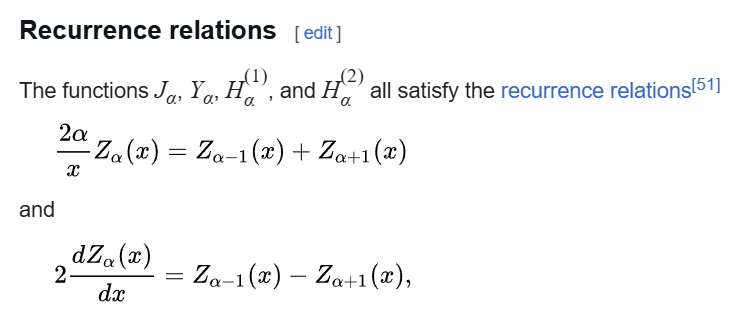

In [1]:
def Q(v, x):
    return jv(v+(3/2), x)/jv(v+(1/2), x)

def Q_prime(v, x):
    return (1/2)*(1 - (jv(v+(5/2), x)*jv(v+(1/2), x) + jv(v+(3/2), x)*jv(v-(1/2), x) - jv(v+(3/2), x)**2)/jv(v+(1/2), x)**2)

### Objective function is F(q), such that it is LHS - RHS of the characteristic transcendental equation
def objective_function(Oh, l, q):
    if Oh == 0:
      return (l)*(l-1)*(l+2) + (q)**4
    else:
      return (l)*(l-1)*(l+2) + (q)**4 - (2*Oh*(q**2)*(l-1)*(l+(l+1)*((q-2*l*(Oh**0.5)*Q(l,(q/(Oh)**0.5)))/(q-2*(Oh**0.5)*Q(l,(q/(Oh)**0.5))))))

def objective_function_prime(Oh, l, q):

    sqrtOh = Oh**0.5
    x = q / sqrtOh

    Qval = Q(l, x)
    Qp = Q_prime(l, x)

    N = q - 2*l*sqrtOh*Qval
    D = q - 2*sqrtOh*Qval

    Np = 1 - 2*l*Qp
    Dp = 1 - 2*Qp

    if Oh == 0:
      return 4*q**3
    else:
      return 4*q**3 - 2*Oh*(l-1)*(2*q*(l + (l+1)*(N/D)) + q**2*(l+1)*( (Np*D - N*Dp) / D**2 ))